In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.linalg import solve_triangular
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox

from non_parametric_pro.density import ProParameters, pro_logdensity_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import posterior_function_draws
from non_parametric_pro.data.synthetic import make_contaminated_data
from non_parametric_pro.gp import _full_gp_basis

from blackjax.util import run_inference_algorithm

jax.config.update("jax_enable_x64", True)

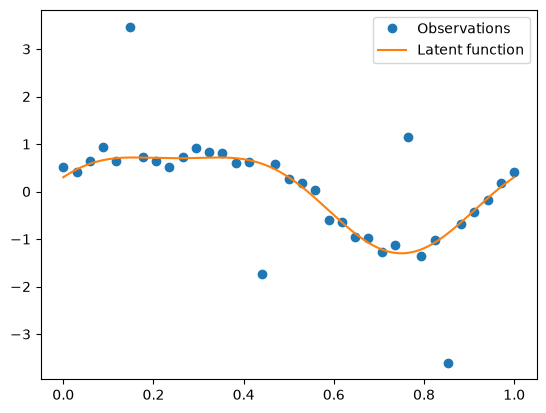

In [36]:
key = jr.PRNGKey(0)

example = make_contaminated_data(key, n_outliers=4)

fig, ax = plt.subplots()
ax.plot(example.x_train, example.y_train, "o", label="Observations")
ax.plot(example.x_test, example.y_truth, label="Latent function")
ax.legend(loc="best")
plt.show()

In [43]:
data = gpx.Dataset(X=example.x_train, y=example.y_train)
kernel = gpx.kernels.RBF(lengthscale=0.5)
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

optim = ox.adam(learning_rate=0.01)

opt_posterior, _ = gpx.fit(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
    optim=optim,
    num_iters=500,
    verbose=False,
)

basis = _full_gp_basis(opt_posterior, data.X, jitter=1e-6)
nu = gpx.objectives._val(opt_posterior.likelihood.obs_stddev)
opt_kernel = opt_posterior.prior.kernel

In [64]:
gp_latent_dist = opt_posterior.predict(example.x_test, train_data=data)
gp_predictive_dist = opt_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

In [55]:
params = ProParameters(
        y=data.y,
        basis=basis,
        step_size=1e-3,
        nu=0.1,
        alpha=1.0,
        tolerance=1e-200,
        jitter=1e-6,
)

J = basis.shape[1]
M = data.n

initial_position = jr.normal(key, (M, J))

ula = parametric_ula(pro_logdensity_fn, params)

out, history = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=ula,
    num_steps=20000,
    initial_position=initial_position,
    progress_bar=True
)

<div><progress max="20000" value="20000"></progress> 100.00% [20000/20000 00:00&lt;?]</div>

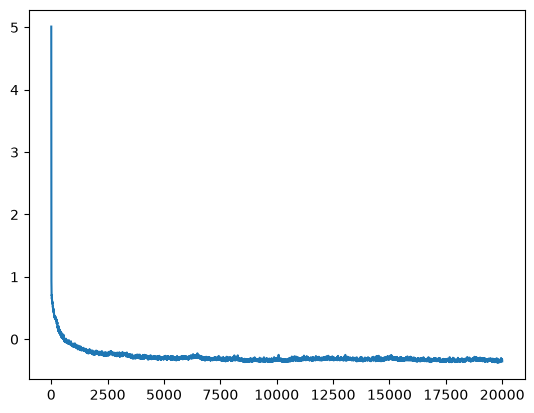

In [56]:
plt.plot(history[1].score)
plt.show()

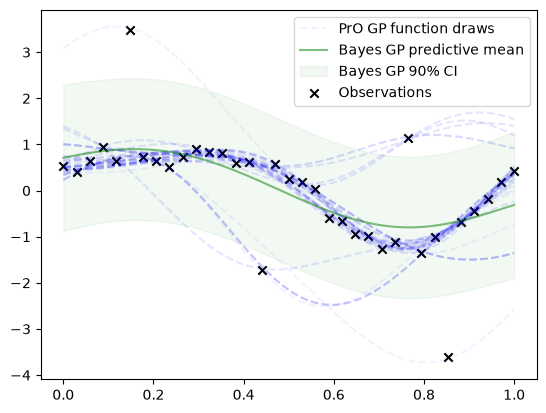

In [76]:
cross_cov = opt_kernel.cross_covariance(example.x_test, example.x_train)
test_basis = solve_triangular(basis, cross_cov.T, lower=True).T
test_cov = opt_kernel.gram(example.x_test).as_matrix()

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    out.position,
    num_draws=60,
    jitter=1e-6,
)

x_plot = example.x_test.squeeze()

plt.plot(x_plot, draws[:, 0], color="blue", alpha=0.05, label="PrO GP function draws", linestyle="--")
plt.plot(x_plot, draws[:, 1:], color="blue", alpha=0.05, linestyle="--")
plt.plot(x_plot, gp_predictive_mean, color="green", alpha=0.5, label="Bayes GP predictive mean")
plt.fill_between(x_plot, gp_predictive_mean - 1.64 * gp_predictive_std, gp_predictive_mean + 1.64 * gp_predictive_std, alpha=0.05, color="green", label="Bayes GP 90% CI")
plt.scatter(example.x_train.squeeze(), example.y_train.squeeze(), color="black", label="Observations", marker="x")
plt.legend()
plt.show()